EC3030 Computational Economics — Assessment 2

In [47]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn as skt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Data

In [48]:
data = pd.read_csv('cps_asec2025_clean.csv')
print('Shape:', data.shape)
data.head()

Shape: (49583, 31)


,YEAR,SERIAL,MONTH,HWTFINL,CPSID,ASECFLAG,ASECWTH,STATEFIP,METRO,PERNUM,...,HISPAN,OCC,IND,CLASSWKR,EDUC,WKSWORK1,UHRSWORKLY,INCWAGE,hourly_wage,log_hwage
0,2025,12,3,NaN,20250101603800,1,15183300,23,1,1,...,0,1360,7290,21,111,52,43,130000,58.139535,4.062846
1,2025,12,3,NaN,20250101603800,1,15183300,23,1,2,...,0,705,7390,21,111,52,43,166000,74.239714,4.307299
2,2025,13,3,NaN,20250103243300,1,15183300,23,1,1,...,0,4810,6992,21,111,52,40,100000,48.076923,3.872802
3,2025,13,3,NaN,20250103243300,1,15183300,23,1,2,...,0,2310,7860,21,123,52,40,113000,54.326923,3.995020
4,2025,15,3,NaN,20231200358100,1,20861500,23,1,1,...,0,300,670,28,81,52,55,80000,27.972028,3.331205


Green Job Classification

In [49]:
green = pd.read_csv('GreenTask_AppA.csv')
green = green[green['Occupation Type'] != 'TOTAL:'].copy()
print('Green occupations:', len(green))

from soc_to_census_occ import soc_to_census_occ

green['SOC6'] = green['Code'].str[:7]
green['census_occ'] = green['SOC6'].map(soc_to_census_occ)

green_occs = set(green['census_occ'].dropna().astype(int).unique())
print('Unique green Census OCC codes:', len(green_occs))

data['green_job'] = data['OCC'].isin(green_occs).astype(int)
print('\nGreen job distribution:')
print(data['green_job'].value_counts())
print(f'Green share: {data["green_job"].mean()*100:.1f}%')

Green occupations: 138
Unique green Census OCC codes: 55

Green job distribution:
green_job
0    44426
1     5157
Name: count, dtype: int64
Green share: 10.4%


Variable Construction

In [50]:
educ_map = {
    2: 0, 10: 4, 20: 6, 30: 8, 40: 9, 50: 10, 60: 11,
    71: 12, 73: 12, 81: 13, 91: 14, 92: 14,
    111: 16, 123: 18, 124: 19, 125: 20
}
data['educ_years'] = data['EDUC'].map(educ_map)

data['exper'] = data['AGE'] - data['educ_years'] - 6
data['exper'] = data['exper'].clip(lower=0)
data['expersq'] = data['exper'] ** 2

data['female'] = (data['SEX'] == 2).astype(int)
data['nonwhite'] = (data['RACE'] != 100).astype(int)
data['hispanic'] = (data['HISPAN'] > 0).astype(int)
data['married'] = (data['MARST'] == 1).astype(int)
data['metro'] = data['METRO'].isin([2, 3, 4]).astype(int)
data['veteran'] = (data['VETSTAT'] == 2).astype(int)
data['citizen'] = data['CITIZEN'].isin([1, 2, 3]).astype(int)

data = data.dropna(subset=['educ_years'])
print('Observations:', len(data))

Observations: 49583


Summary Statistics

In [51]:
vars_to_compare = ['log_hwage', 'hourly_wage', 'educ_years', 'exper',
                    'female', 'nonwhite', 'hispanic', 'married', 'metro',
                    'veteran', 'citizen', 'NCHILD']

summary = data.groupby('green_job')[vars_to_compare].mean().round(3).T
summary.columns = ['Non-Green', 'Green']
summary['Difference'] = summary['Green'] - summary['Non-Green']
print(summary)

             Non-Green   Green  Difference
log_hwage        3.383   3.604       0.221
hourly_wage     37.464  48.339      10.875
educ_years      14.362  14.795       0.433
exper           22.598  22.575      -0.023
female           0.495   0.444      -0.051
nonwhite         0.240   0.207      -0.033
hispanic         0.219   0.175      -0.044
married          0.583   0.618       0.035
metro            0.839   0.858       0.019
veteran          0.048   0.043      -0.005
citizen          0.791   0.809       0.018
NCHILD           1.049   1.062       0.013


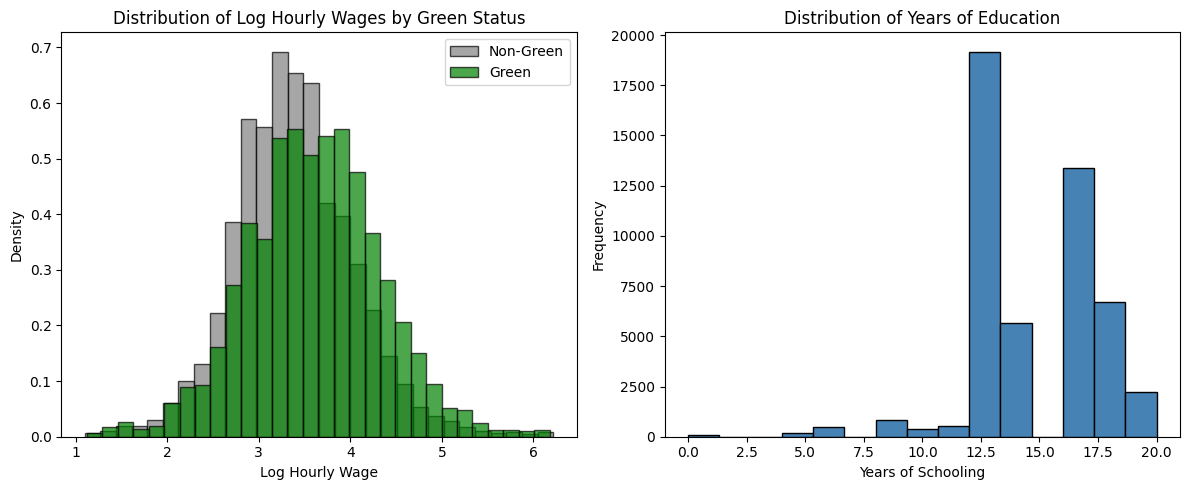

In [52]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ax1.hist(data[data['green_job']==0]['log_hwage'], bins=30, edgecolor='black',
         color='grey', alpha=0.7, label='Non-Green', density=True)
ax1.hist(data[data['green_job']==1]['log_hwage'], bins=30, edgecolor='black',
         color='green', alpha=0.7, label='Green', density=True)
ax1.set_title('Distribution of Log Hourly Wages by Green Status')
ax1.set_xlabel('Log Hourly Wage')
ax1.set_ylabel('Density')
ax1.legend()

ax2.hist(data['educ_years'], bins=15, edgecolor='black', color='steelblue')
ax2.set_title('Distribution of Years of Education')
ax2.set_xlabel('Years of Schooling')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150)
plt.show()

EDA

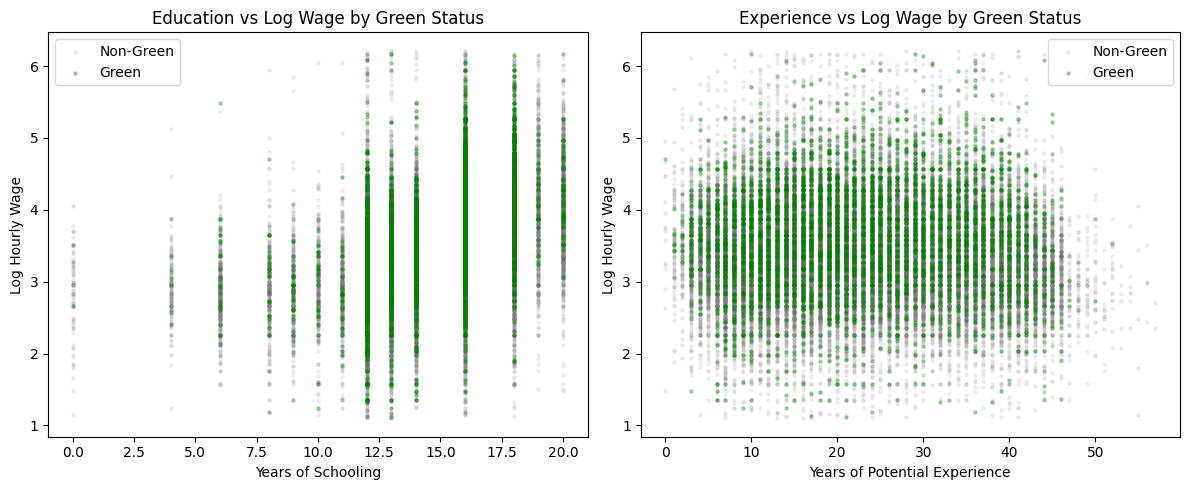

In [53]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ax1.scatter(data[data['green_job']==0]['educ_years'],
            data[data['green_job']==0]['log_hwage'],
            alpha=0.1, color='grey', label='Non-Green', s=5)
ax1.scatter(data[data['green_job']==1]['educ_years'],
            data[data['green_job']==1]['log_hwage'],
            alpha=0.3, color='green', label='Green', s=5)
ax1.set_title('Education vs Log Wage by Green Status')
ax1.set_xlabel('Years of Schooling')
ax1.set_ylabel('Log Hourly Wage')
ax1.legend()

ax2.scatter(data[data['green_job']==0]['exper'],
            data[data['green_job']==0]['log_hwage'],
            alpha=0.1, color='grey', label='Non-Green', s=5)
ax2.scatter(data[data['green_job']==1]['exper'],
            data[data['green_job']==1]['log_hwage'],
            alpha=0.3, color='green', label='Green', s=5)
ax2.set_title('Experience vs Log Wage by Green Status')
ax2.set_xlabel('Years of Potential Experience')
ax2.set_ylabel('Log Hourly Wage')
ax2.legend()

plt.tight_layout()
plt.savefig('fig2_scatter.png', dpi=150)
plt.show()

OLS Regression

In [54]:
formula = ('log_hwage ~ green_job + educ_years + exper + expersq + female '
           '+ nonwhite + hispanic + married + metro + veteran + citizen + NCHILD')

ols_model = smf.ols(formula=formula, data=data)
ols_results = ols_model.fit()
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:              log_hwage   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     1541.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        15:49:45   Log-Likelihood:                -42564.
No. Observations:               49583   AIC:                         8.515e+04
Df Residuals:                   49570   BIC:                         8.527e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6138      0.021     76.717      0.0

Ridge and Lasso

In [55]:
y = data['log_hwage'].values

X_vars = ['green_job', 'educ_years', 'exper', 'expersq', 'female',
          'nonwhite', 'hispanic', 'married', 'metro', 'veteran', 'citizen', 'NCHILD']

X_reg = data[X_vars].values

ols_sk = skt.linear_model.LinearRegression(fit_intercept=True).fit(X_reg, y)

alphas = [0.01, 0.1, 1, 10]

ridge_models = {}
lasso_models = {}
for a in alphas:
    ridge_models[a] = skt.linear_model.Ridge(alpha=a, fit_intercept=True).fit(X_reg, y)
    lasso_models[a] = skt.linear_model.Lasso(alpha=a, fit_intercept=True, max_iter=10000).fit(X_reg, y)

print(f"{'Variable':<15}", f"{'OLS':>8}", end='')
for a in alphas:
    print(f"  {'Ridge '+str(a):>10}", end='')
for a in alphas:
    print(f"  {'Lasso '+str(a):>10}", end='')
print()
print('-' * 130)

# Intercept
print(f"{'intercept':<15} {ols_sk.intercept_:>8.4f}", end='')
for a in alphas:
    print(f"  {ridge_models[a].intercept_:>10.4f}", end='')
for a in alphas:
    print(f"  {lasso_models[a].intercept_:>10.4f}", end='')
print()

for i, name in enumerate(X_vars):
    print(f"{name:<15} {ols_sk.coef_[i]:>8.4f}", end='')
    for a in alphas:
        print(f"  {ridge_models[a].coef_[i]:>10.4f}", end='')
    for a in alphas:
        print(f"  {lasso_models[a].coef_[i]:>10.4f}", end='')
    print()

Variable             OLS  Ridge 0.01   Ridge 0.1     Ridge 1    Ridge 10  Lasso 0.01   Lasso 0.1     Lasso 1    Lasso 10
----------------------------------------------------------------------------------------------------------------------------------
intercept         1.6138      1.6138      1.6138      1.6138      1.6138      1.6314      1.8889      3.4442      3.4256
green_job         0.1466      0.1466      0.1466      0.1466      0.1463      0.0477      0.0000      0.0000      0.0000
educ_years        0.1054      0.1054      0.1054      0.1054      0.1054      0.1090      0.0980      0.0000      0.0000
exper             0.0112      0.0112      0.0112      0.0112      0.0112      0.0117      0.0054      0.0000     -0.0000
expersq          -0.0001     -0.0001     -0.0001     -0.0001     -0.0001     -0.0001     -0.0000     -0.0001     -0.0000
female           -0.2382     -0.2382     -0.2382     -0.2382     -0.2380     -0.2032     -0.0000     -0.0000     -0.0000
nonwhite         -0.05

Train/Test Split and MSE

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} obs | Test: {X_test.shape[0]} obs')

ols_train = skt.linear_model.LinearRegression(fit_intercept=True).fit(X_train, y_train)
ridge_train = skt.linear_model.Ridge(alpha=1, fit_intercept=True).fit(X_train, y_train)
lasso_train = skt.linear_model.Lasso(alpha=0.01, fit_intercept=True, max_iter=10000).fit(X_train, y_train)

models = {'OLS': ols_train, 'Ridge(1)': ridge_train, 'Lasso(0.01)': lasso_train}

print(f"\n{'Model':<15} {'Train MSE':>12} {'Test MSE':>12}")
print('-' * 40)
for name, model in models.items():
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))
    print(f"{name:<15} {train_mse:>12.6f} {test_mse:>12.6f}")

Train: 39666 obs | Test: 9917 obs

Model              Train MSE     Test MSE
----------------------------------------
OLS                 0.324880     0.330397
Ridge(1)            0.324880     0.330397
Lasso(0.01)         0.328836     0.334334


Diagnostic Tests

In [57]:
from statsmodels.stats.diagnostic import het_breuschpagan

ols_robust = smf.ols(formula, data=data).fit(cov_type='HC1')

bp_stat, bp_pval, _, _ = het_breuschpagan(
    ols_results.resid, ols_results.model.exog
)

print("Breusch-Pagan Test")
print(f"LM statistic : {bp_stat:.4f}")
print(f"p-value      : {bp_pval:.4e}")
print(f"Reject H0 at 5%: {bp_pval < 0.05}\n")

print(f"{'Variable':<15} {'Coef':>8} {'OLS SE':>10} {'Robust SE':>10} {'OLS t':>8} {'Rob t':>8}")
print("-" * 65)
for var in ['green_job', 'educ_years', 'exper', 'female', 'nonwhite', 'metro']:
    coef = ols_results.params[var]
    se_ols = ols_results.bse[var]
    se_robust = ols_robust.bse[var]
    t_ols = ols_results.tvalues[var]
    t_robust = ols_robust.tvalues[var]
    print(f"{var:<15} {coef:>8.4f} {se_ols:>10.4f} {se_robust:>10.4f} {t_ols:>8.4f} {t_robust:>8.4f}")

Breusch-Pagan Test
LM statistic : 196.4571
p-value      : 1.7552e-35
Reject H0 at 5%: True

Variable            Coef     OLS SE  Robust SE    OLS t    Rob t
-----------------------------------------------------------------
green_job         0.1466     0.0084     0.0089  17.4052  16.5552
educ_years        0.1054     0.0010     0.0011 100.8565  93.0068
exper             0.0112     0.0010     0.0011  10.8659  10.6175
female           -0.2382     0.0052     0.0053 -45.3916 -45.1997
nonwhite         -0.0519     0.0066     0.0066  -7.9185  -7.8724
metro             0.1429     0.0072     0.0069  19.8948  20.5712


VIF

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = ['green_job', 'educ_years', 'exper', 'expersq',
            'female', 'nonwhite', 'hispanic', 'married', 'metro',
            'veteran', 'citizen', 'NCHILD']
X_vif = data[vif_vars].values

print("Variance Inflation Factors")
print(f"{'Variable':<15} {'VIF':>8}")
print("-" * 25)
for i, var in enumerate(vif_vars):
    vif_val = variance_inflation_factor(X_vif, i)
    print(f"{var:<15} {vif_val:>8.2f}")

Variance Inflation Factors
Variable             VIF
-------------------------
green_job           1.12
educ_years         17.92
exper              83.03
expersq            42.98
female              2.05
nonwhite            1.49
hispanic            1.48
married             3.04
metro               6.27
veteran             1.09
citizen             5.51
NCHILD              2.27


RESET

In [59]:
from statsmodels.stats.diagnostic import linear_reset

reset_result = linear_reset(ols_results, power=3, use_f=True)

print("Ramsey RESET Test (powers 2 & 3)")
print(f"F-statistic : {reset_result.fvalue:.4f}")
print(f"p-value     : {reset_result.pvalue:.4e}")
print(f"Reject H0 at 5%: {reset_result.pvalue < 0.05}")

Ramsey RESET Test (powers 2 & 3)
F-statistic : 335.5828
p-value     : 1.7224e-145
Reject H0 at 5%: True


Lasso Coefficient Path

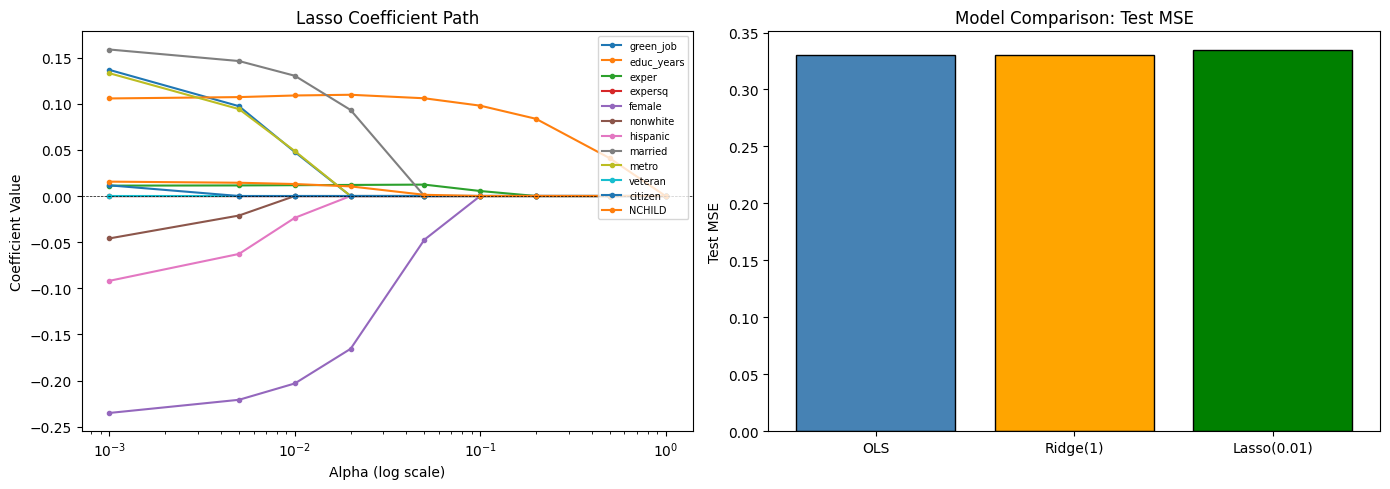

In [60]:
alphas_path = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

coef_matrix = np.zeros((len(alphas_path), len(X_vars)))
for j, a in enumerate(alphas_path):
    lasso_j = skt.linear_model.Lasso(alpha=a, fit_intercept=True, max_iter=10000).fit(X_reg, y)
    coef_matrix[j, :] = lasso_j.coef_

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

for i, name in enumerate(X_vars):
    ax1.plot(alphas_path, coef_matrix[:, i], marker='o', markersize=3, label=name)

ax1.set_xscale('log')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Coefficient Value')
ax1.set_title('Lasso Coefficient Path')
ax1.legend(fontsize=7, loc='upper right')
ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

mse_vals = []
mse_labels = []
for name, model in models.items():
    mse_vals.append(mean_squared_error(y_test, model.predict(X_test)))
    mse_labels.append(name)

ax2.bar(mse_labels, mse_vals, color=['steelblue', 'orange', 'green'], edgecolor='black')
ax2.set_ylabel('Test MSE')
ax2.set_title('Model Comparison: Test MSE')

plt.tight_layout()
plt.savefig('fig3_lasso_path_mse.png', dpi=150)
plt.show()

In [61]:
print(f"{'Alpha':<8}", end='')
for name in X_vars:
    print(f"  {name:>12}", end='')
print()
print('-' * 160)
for j, a in enumerate(alphas_path):
    print(f"{a:<8}", end='')
    for i in range(len(X_vars)):
        val = coef_matrix[j, i]
        if abs(val) < 1e-6:
            print(f"  {'0':>12}", end='')
        else:
            print(f"  {val:>12.4f}", end='')
    print()

Alpha        green_job    educ_years         exper       expersq        female      nonwhite      hispanic       married         metro       veteran       citizen        NCHILD
----------------------------------------------------------------------------------------------------------------------------------------------------------------
0.001           0.1367        0.1058        0.0112       -0.0001       -0.2352       -0.0459       -0.0919        0.1588        0.1331             0        0.0116        0.0156
0.005           0.0974        0.1072        0.0115       -0.0001       -0.2209       -0.0212       -0.0628        0.1463        0.0942             0             0        0.0144
0.01            0.0477        0.1090        0.0117       -0.0001       -0.2032             0       -0.0236        0.1304        0.0487             0             0        0.0130
0.02                 0        0.1098        0.0120       -0.0001       -0.1657             0             0        0.0933           